# Sowing Success: How Machine Learning Helps Farmers Select the Best Crops

![Farmer in a field](farmer_in_a_field.jpg)

Measuring essential soil metrics such as nitrogen, phosphorous, potassium levels, and pH value is an important aspect of assessing soil condition. However, it can be an expensive and time-consuming process, which can cause farmers to prioritize which metrics to measure based on their budget constraints.

Farmers have various options when it comes to deciding which crop to plant each season. Their primary objective is to maximize the yield of their crops, taking into account different factors. One crucial factor that affects crop growth is the condition of the soil in the field, which can be assessed by measuring basic elements such as nitrogen and potassium levels. Each crop has an ideal soil condition that ensures optimal growth and maximum yield.

A farmer reached out to you as a machine learning expert for assistance in selecting the best crop for his field. They've provided you with a dataset called `soil_measures.csv`, which contains:

- `"N"`: Nitrogen content ratio in the soil
- `"P"`: Phosphorous content ratio in the soil
- `"K"`: Potassium content ratio in the soil
- `"pH"` value of the soil
- `"crop"`: categorical values that contain various crops (target variable).

Each row in this dataset represents various measures of the soil in a particular field. Based on these measurements, the crop specified in the `"crop"` column is the optimal choice for that field.  

In this project, you will build multi-class classification models to predict the type of `"crop"` and identify the single most importance feature for predictive performance.

# Import Modules

In [74]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score

# Read Data

In [77]:
# Load the dataset
crops = pd.read_csv("soil_measures.csv")

In [79]:
crops.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


# Exploratory Data Analysis

In [82]:
crops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [84]:
crops.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


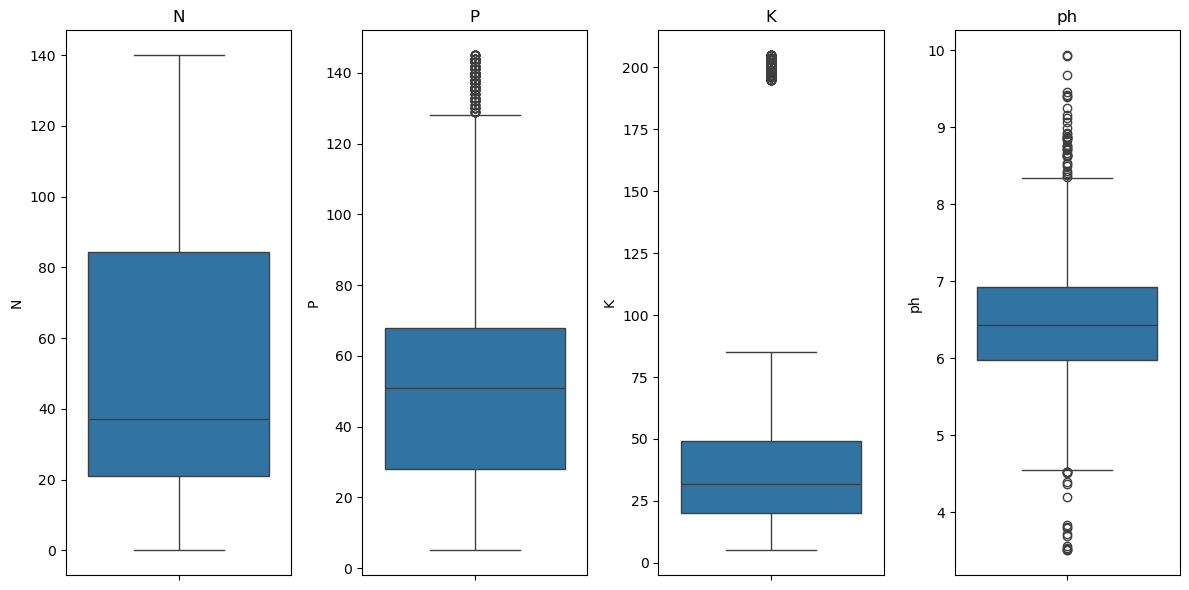

In [86]:
features = ['N', 'P', 'K', 'ph']

# Plot boxplots for each numeric feature
plt.figure(figsize=(12, 6))
for i, feature in enumerate(features):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=crops[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

In [87]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers
    
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

def has_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)].shape[0] > 0


In [90]:
for col in ['N', 'P', 'K', 'ph']:
    outliers = detect_outliers_iqr(crops, col)
    print(f'{col}: {len(outliers)} outliers')

N: 0 outliers
P: 138 outliers
K: 200 outliers
ph: 57 outliers


In [92]:
crops_cleaned = crops.copy()

# Repeat until no outliers are left in any specified column
columns = ['N', 'P', 'K', 'ph']
outliers_remaining = True

while outliers_remaining:
    outliers_remaining = False
    for col in columns:
        if has_outliers(crops_cleaned, col):
            crops_cleaned = remove_outliers_iqr(crops_cleaned, col)
            outliers_remaining = True

print(f"Original dataset: {len(crops)} rows")
print(f"Cleaned dataset: {len(crops_cleaned)} rows (no outliers remaining)")

Original dataset: 2200 rows
Cleaned dataset: 1897 rows (no outliers remaining)


In [94]:
scaler = MinMaxScaler()
features_to_scale = ['N', 'P', 'K', 'ph']

# Scale only numeric columns
crops_cleaned[features_to_scale] = scaler.fit_transform(crops_cleaned[features_to_scale])

print(crops_cleaned.head())

          N         P         K        ph  crop
0  0.642857  0.411111  0.493506  0.504004  rice
1  0.607143  0.588889  0.467532  0.655455  rice
2  0.428571  0.555556  0.506494  0.882475  rice
3  0.528571  0.333333  0.454545  0.639126  rice
4  0.557143  0.411111  0.480519  0.822548  rice


In [96]:
before = len(crops_cleaned)
crops_cleaned = crops_cleaned.drop_duplicates()
after = len(crops_cleaned)

print(f"Removed {before - after} duplicate rows.")

Removed 0 duplicate rows.


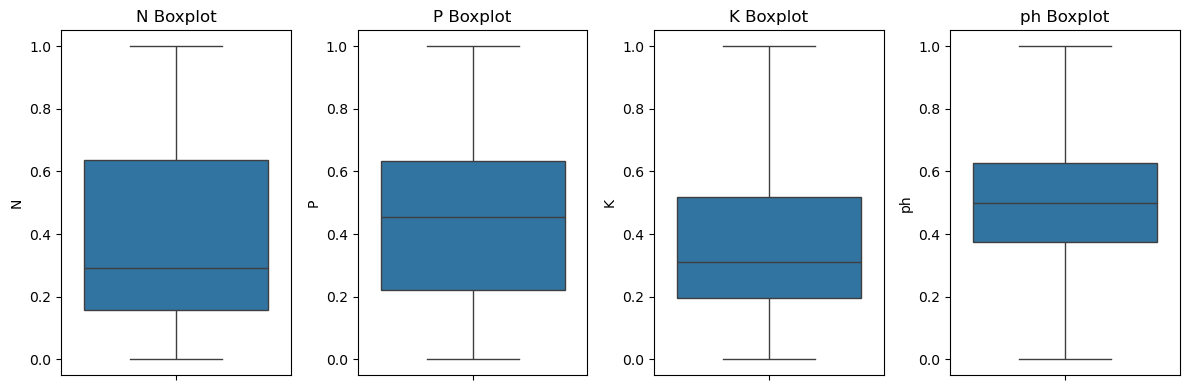

In [98]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(['N', 'P', 'K', 'ph']):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=crops_cleaned[col])
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()


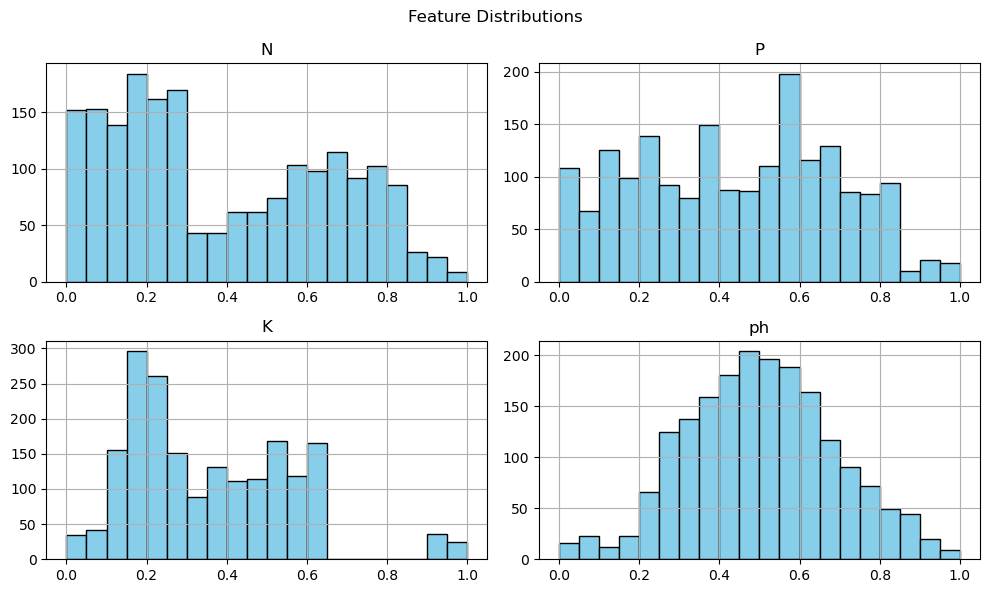

In [99]:
crops_cleaned[['N', 'P', 'K', 'ph']].hist(figsize=(10, 6), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()


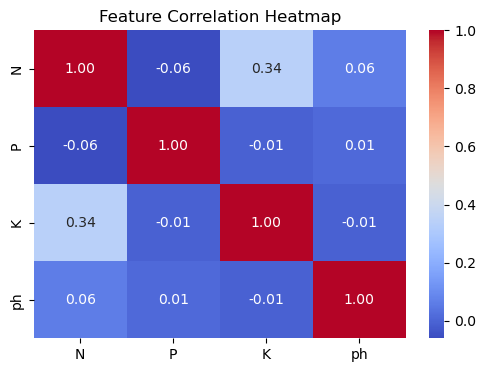

In [101]:
plt.figure(figsize=(6, 4))
sns.heatmap(crops_cleaned[['N', 'P', 'K', 'ph']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


/var/folders/56/hp85dts9479fwkf8mhb3ljg80000gn/T/ipykernel_6106/4277554884.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='crop', data=crops_cleaned, order=crops_cleaned['crop'].value_counts().index, palette='viridis')


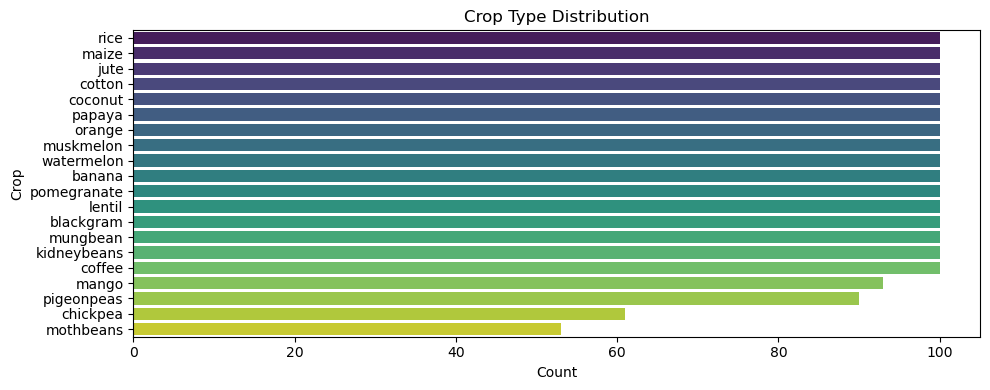

In [103]:
plt.figure(figsize=(10, 4))
sns.countplot(y='crop', data=crops_cleaned, order=crops_cleaned['crop'].value_counts().index, palette='viridis')
plt.title('Crop Type Distribution')
plt.xlabel('Count')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

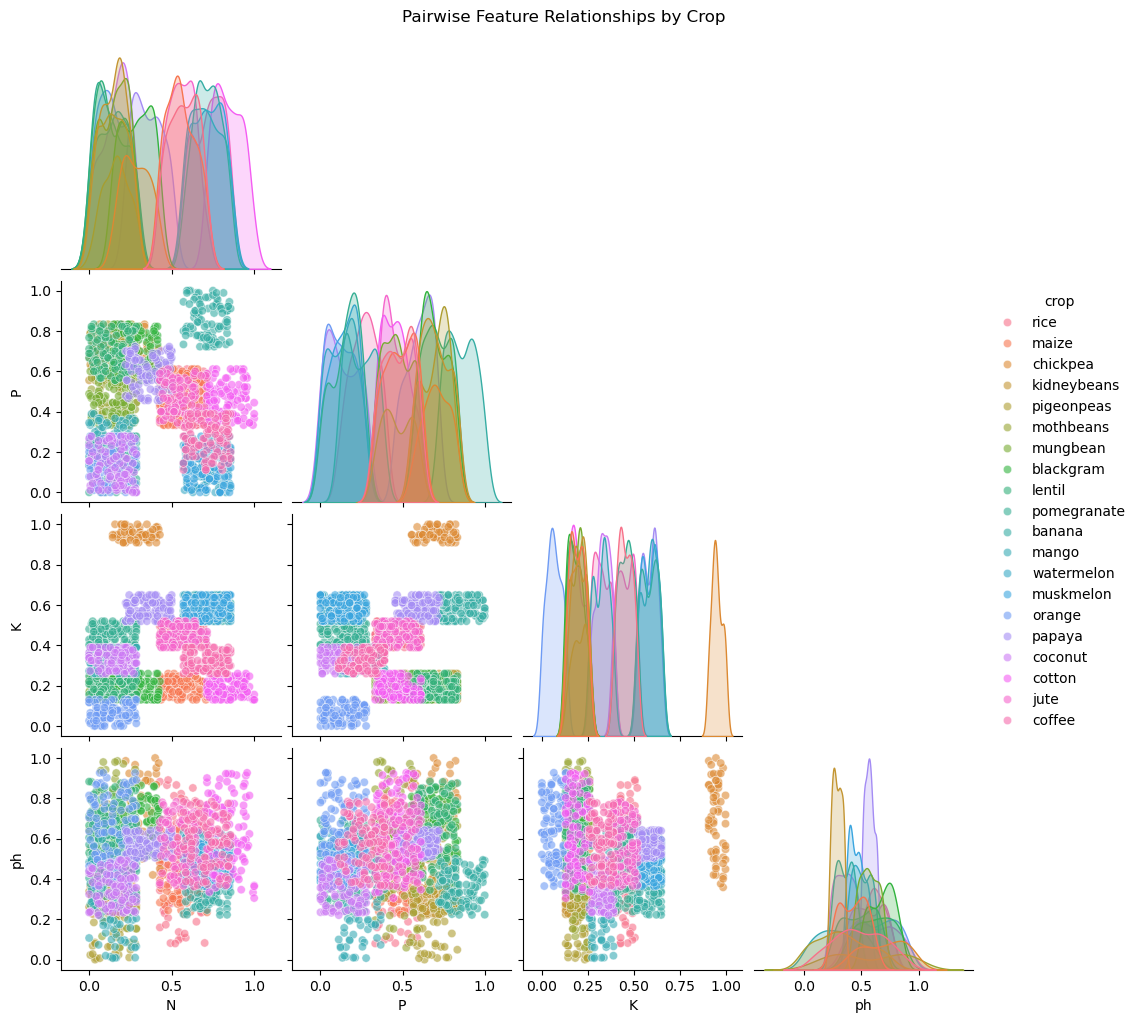

In [106]:
sns.pairplot(crops_cleaned, vars=['N', 'P', 'K', 'ph'], hue='crop', corner=True, plot_kws={'alpha': 0.6})
plt.suptitle("Pairwise Feature Relationships by Crop", y=1.02)
plt.show()

# Logistic Regression (with softmax for multi-class)

In [108]:
# Label encoding the 'crop' column
le = LabelEncoder()
crops_cleaned['crop_encoded'] = le.fit_transform(crops_cleaned['crop'])

In [109]:
# Features (independent variables)
X = crops_cleaned[['N', 'P', 'K', 'ph']]

# Target (dependent variable)
y = crops_cleaned['crop_encoded']

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create pipeline: scaling + logistic regression
model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))

# Hyperparameter grid
param_grid = {
    'logisticregression__solver': ['lbfgs', 'saga', 'newton-cg'],
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__max_iter': [100, 500, 1000],
}

# Grid search with 5-fold CV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best model and parameters
print("Best Hyperparameters:", grid_search.best_params_)

# Predict and evaluate
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge

Best Hyperparameters: {'logisticregression__C': 1, 'logisticregression__max_iter': 100, 'logisticregression__solver': 'lbfgs'}


In [143]:
# Get best hyperparameters from grid search
best_params = grid_search.best_params_

# Extract best hyperparameter values
best_solver = best_params['logisticregression__solver']
best_C = best_params['logisticregression__C']
best_max_iter = best_params['logisticregression__max_iter']

# Evaluate each feature using the best-found model settings
feature_scores = {}

for feature in X.columns:
    X_single = X[[feature]]
    
    X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
        X_single, y, test_size=0.2, random_state=42
    )
    
    model_single = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            random_state=42,
            solver=best_solver,
            C=best_C,
            max_iter=best_max_iter
        )
    )
    
    model_single.fit(X_train_single, y_train_single)
    y_pred_single = model_single.predict(X_test_single)
    
    score = balanced_accuracy_score(y_test_single, y_pred_single)
    feature_scores[feature] = score

best_feature = max(feature_scores, key=feature_scores.get)
best_score = feature_scores[best_feature]
best_predictive_feature = {best_feature: best_score}

print(feature_scores)

print("\n\nBest Predictive Feature (by balanced accuracy):")
print(best_predictive_feature)


{'N': 0.18082246056317264, 'P': 0.15608142508095396, 'K': 0.2670573492554916, 'ph': 0.11608225108225108}


Best Predictive Feature (by balanced accuracy):
{'K': 0.2670573492554916}


# Decision Trees

In [162]:
# Feature and target selection
X = crops_cleaned[['N', 'P', 'K', 'ph']]
y = crops_cleaned['crop']

# Encode crop labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Define the pipeline
pipeline = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(random_state=42)
)

# Define hyperparameters to search
param_grid = {
    'decisiontreeclassifier__max_depth': [3, 5, 10, 20, None],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 4],
    'decisiontreeclassifier__criterion': ['gini', 'entropy'],
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predict with the best model
y_pred = best_model.predict(X_test)

# Report
print("Best Parameters:", grid_search.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'decisiontreeclassifier__criterion': 'entropy', 'decisiontreeclassifier__max_depth': 10, 'decisiontreeclassifier__min_samples_leaf': 2, 'decisiontreeclassifier__min_samples_split': 2}

Classification Report:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        22
   blackgram       0.53      0.83      0.65        12
    chickpea       1.00      1.00      1.00        15
     coconut       0.91      0.88      0.89        24
      coffee       1.00      0.96      0.98        23
      cotton       0.95      1.00      0.97        19
        jute       0.60      0.95      0.74        22
 kidneybeans       0.72      0.95      0.82        22
      lentil       0.67      0.47      0.55        17
       maize       1.00      0.94      0.97        17
       mango       0.71      0.86      0.77        14
   mothbeans       1.00      0.69      0.82        13
    mungb

In [164]:
# Extract best parameters from grid search
best_params = grid_search.best_params_

# Remove the prefix added by the pipeline
dt_best_params = {
    key.split("__")[1]: value
    for key, value in best_params.items()
}

# Evaluate each feature using the best Decision Tree config
feature_scores = {}

for feature in X.columns:
    X_single = X[[feature]]
    
    # Train-test split for this single feature
    X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
        X_single, y_encoded, test_size=0.2, random_state=42
    )
    
    # Use best model config in the pipeline
    model_single = make_pipeline(
        StandardScaler(),
        DecisionTreeClassifier(random_state=42, **dt_best_params)
    )
    
    # Train and predict
    model_single.fit(X_train_single, y_train_single)
    y_pred_single = model_single.predict(X_test_single)
    
    # Evaluate using balanced accuracy
    score = balanced_accuracy_score(y_test_single, y_pred_single)
    feature_scores[feature] = score

# Find the best single predictive feature
best_feature = max(feature_scores, key=feature_scores.get)
best_score = feature_scores[best_feature]
best_predictive_feature = {best_feature: best_score}

# Output results
print(feature_scores)

print("\n\nBest Predictive Feature (by balanced accuracy):")
print(best_predictive_feature)


{'N': 0.15899889152665433, 'P': 0.16958067221063589, 'K': 0.28864600090088033, 'ph': 0.11206846665471648}


Best Predictive Feature (by balanced accuracy):
{'K': 0.28864600090088033}


# Random Forest

In [166]:
X = crops_cleaned[['N', 'P', 'K', 'ph']]
y = crops_cleaned['crop']  

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [168]:
# Define the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [None, 10, 20, 30],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],    
    'max_features': ['sqrt', 'log2', None], 
}

# Grid search
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best model
best_rf_model = grid_search.best_estimator_
print("Best Hyperparameters: ", grid_search.best_params_)

# Predict
y_pred = best_rf_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters:  {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 82.63%

Classification Report:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        22
   blackgram       0.56      0.83      0.67        12
    chickpea       1.00      1.00      1.00        15
     coconut       0.92      1.00      0.96        24
      coffee       1.00      1.00      1.00        23
      cotton       0.95      1.00      0.97        19
        jute       0.59      0.91      0.71        22
 kidneybeans       0.71      0.91      0.80        22
      lentil       0.50      0.53      0.51        17
       maize       1.00      0.94      0.97        17
       mango       1.00      0.86      0.92        14
   mothbeans       1.00      0.85      0.92        13
    mungbean       0.86      0.96      0.91        25
   mu

In [169]:
# Extract best hyperparameters
rf_best_params = grid_search.best_params_

# Evaluate each feature using best RF configuration
feature_scores_rf = {}

for feature in X.columns:
    X_single = X[[feature]]
    
    # Split data for this feature only
    X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
        X_single, y_encoded, test_size=0.2, random_state=42
    )
    
    # Create pipeline with best RF model
    model_single_rf = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(random_state=42, **rf_best_params)
    )
    
    # Train and predict
    model_single_rf.fit(X_train_single, y_train_single)
    y_pred_single = model_single_rf.predict(X_test_single)
    
    # Evaluate using balanced accuracy
    score = balanced_accuracy_score(y_test_single, y_pred_single)
    feature_scores_rf[feature] = score

# Find best single feature
best_feature_rf = max(feature_scores_rf, key=feature_scores_rf.get)
best_score_rf = feature_scores_rf[best_feature_rf]
best_predictive_feature_rf = {best_feature_rf: best_score_rf}

# Output
print("\nRandom Forest - Single Feature Scores:")
print(feature_scores_rf)

print("\nBest Predictive Feature (RF, by balanced accuracy):")
print(best_predictive_feature_rf)



Random Forest - Single Feature Scores:
{'N': 0.1587864540449007, 'P': 0.16760930794202433, 'K': 0.2862837125072621, 'ph': 0.135172176412451}

Best Predictive Feature (RF, by balanced accuracy):
{'K': 0.2862837125072621}


# Support Vector Machines (with one-vs-rest or one-vs-one strategies)

In [172]:
X = crops_cleaned[['N', 'P', 'K', 'ph']]
y = crops_cleaned['crop']  

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [174]:
# Define pipeline with scaling and SVM (SVC)
svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC()
)

# Define hyperparameter grid
param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ['scale', 'auto']
}

# Grid search
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best model
best_svm_model = grid_search.best_estimator_
print("Best Hyperparameters (SVM):", grid_search.best_params_)

# Predict
y_pred = best_svm_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Hyperparameters (SVM): {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
SVM Accuracy: 82.89%

Classification Report:
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        22
   blackgram       0.65      0.92      0.76        12
    chickpea       1.00      1.00      1.00        15
     coconut       0.89      1.00      0.94        24
      coffee       0.96      0.96      0.96        23
      cotton       0.95      1.00      0.97        19
        jute       0.62      0.73      0.67        22
 kidneybeans       0.69      1.00      0.81        22
      lentil       0.60      0.71      0.65        17
       maize       1.00      1.00      1.00        17
       mango       1.00      0.93      0.96        14
   mothbeans       1.00      0.69      0.82        13
    mungbean       0.79      0.92      0.85        25
   muskmelon       0.57      0.76      0.65      

In [175]:
# Extract best parameters and clean the prefix
svm_best_params = {
    key.split("__")[1]: value
    for key, value in grid_search.best_params_.items()
}

# Evaluate each feature using best SVM config
feature_scores_svm = {}

for feature in X.columns:
    X_single = X[[feature]]

    # Train-test split
    X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
        X_single, y_encoded, test_size=0.2, random_state=42
    )

    # Build pipeline using best SVM params
    model_single_svm = make_pipeline(
        StandardScaler(),
        SVC(**svm_best_params)
    )

    # Train and predict
    model_single_svm.fit(X_train_single, y_train_single)
    y_pred_single = model_single_svm.predict(X_test_single)

    # Evaluate using balanced accuracy
    score = balanced_accuracy_score(y_test_single, y_pred_single)
    feature_scores_svm[feature] = score

# Identify best predictive feature
best_feature_svm = max(feature_scores_svm, key=feature_scores_svm.get)
best_score_svm = feature_scores_svm[best_feature_svm]
best_predictive_feature_svm = {best_feature_svm: best_score_svm}

# Output
print("\nSVM - Single Feature Scores:")
print(feature_scores_svm)

print("\nBest Predictive Feature (SVM, by balanced accuracy):")
print(best_predictive_feature_svm)



SVM - Single Feature Scores:
{'N': 0.1805591518904212, 'P': 0.16462892146665198, 'K': 0.26766516893838876, 'ph': 0.15671585613650496}

Best Predictive Feature (SVM, by balanced accuracy):
{'K': 0.26766516893838876}
